In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LassoCV, ElasticNetCV
# from ngboost import NGBRegressor
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import lasso_path

from utils.utils import PolicyEDA, FeatureEngineering, DataCleaningUtils


/home/tony-ubuntu/anaconda3/envs/cpa_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
eda_utils = PolicyEDA()
dcu = DataCleaningUtils()
fe = FeatureEngineering()

In [4]:
SCRIPT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
DATA_DIR_PATH = os.path.join(ROOT_DIR_PATH, "data")
PROCESSED_DATA_DIR_PATH = os.path.join(DATA_DIR_PATH, "processed_data")
RESULTS_DIR_PATH = os.path.join(SCRIPT_DIR_PATH, "results")

In [5]:
# Load the emissions data
emissions_df = pd.read_csv(os.path.join(PROCESSED_DATA_DIR_PATH, "total_emissions.csv"))
emissions_df.head()

,iso_alpha_3,income_group,region,year,total_emissions
0,ABW,High income,Latin America & Caribbean,2000,0.335765
1,ABW,High income,Latin America & Caribbean,2001,0.344135
2,ABW,High income,Latin America & Caribbean,2002,0.363222
3,ABW,High income,Latin America & Caribbean,2003,0.412246
4,ABW,High income,Latin America & Caribbean,2004,0.430187


In [6]:
emissions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4485 entries, 0 to 4484
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   iso_alpha_3      4485 non-null   object 
 1   income_group     4485 non-null   object 
 2   region           4485 non-null   object 
 3   year             4485 non-null   int64  
 4   total_emissions  4485 non-null   float64
dtypes: float64(1), int64(1), object(3)
memory usage: 175.3+ KB


In [7]:
# Load the wb controls
wb_controls_df = pd.read_csv(os.path.join(PROCESSED_DATA_DIR_PATH, "wb_control_vars.csv"))
wb_controls_df.head()

,year,pop_growth,pop_total,pop_urban_pct,poverty_headcount_ratio,access_to_electricity_pct,electricity_consumption_per_capita_kwh,energy_use_per_capita_kg_of_oil_equivalent,energy_use_kg_of_oil_equivalent_per_gdp,electricity_from_coal_pct,electricity_from_natural_gas_pct,electricity_from_renewables_pct,renewable_energy_consumption_pct,forest_area_pct,agriculture_value_added_pct,annual_freshwater_withdrawals_pct,iso_alpha_3
0,2022,2.626659,731821393.0,37.909012,NaN,48.801258,497.161668,565.488909,136.911837,53.452960,3.020806,NaN,NaN,29.737205,13.840745,NaN,NaN
1,2021,2.684849,713090928.0,37.393633,NaN,48.127211,513.745842,570.998888,139.730030,54.663797,2.615079,4.939318,NaN,29.955194,13.404438,5.041739,NaN
2,2020,2.736283,694446100.0,36.884034,NaN,46.282371,512.766661,563.976201,140.687987,56.721763,2.449528,4.585792,66.123449,30.174252,14.644268,5.012011,NaN
3,2019,2.759057,675950189.0,36.384272,NaN,44.390861,548.496602,586.441491,138.644201,58.600950,2.731900,5.173796,63.387090,30.391626,12.627574,4.960944,NaN
4,2018,2.771987,657801085.0,35.893398,NaN,43.035073,568.141299,583.763039,137.485602,60.485772,2.035550,3.945917,62.242631,30.611512,11.913986,4.917538,NaN


In [8]:
wb_controls_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6118 entries, 0 to 6117
Data columns (total 17 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   year                                        6118 non-null   int64  
 1   pop_growth                                  6094 non-null   float64
 2   pop_total                                   6095 non-null   float64
 3   pop_urban_pct                               6049 non-null   float64
 4   poverty_headcount_ratio                     2049 non-null   float64
 5   access_to_electricity_pct                   6024 non-null   float64
 6   electricity_consumption_per_capita_kwh      4437 non-null   float64
 7   energy_use_per_capita_kg_of_oil_equivalent  4565 non-null   float64
 8   energy_use_kg_of_oil_equivalent_per_gdp     4404 non-null   float64
 9   electricity_from_coal_pct                   5747 non-null   float64
 10  electricity_

In [9]:
indicators_and_emissions_df = pd.merge(emissions_df, wb_controls_df, on=["iso_alpha_3", "year"], how="left")
indicators_and_emissions_df.head()

,iso_alpha_3,income_group,region,year,total_emissions,pop_growth,pop_total,pop_urban_pct,poverty_headcount_ratio,access_to_electricity_pct,electricity_consumption_per_capita_kwh,energy_use_per_capita_kg_of_oil_equivalent,energy_use_kg_of_oil_equivalent_per_gdp,electricity_from_coal_pct,electricity_from_natural_gas_pct,electricity_from_renewables_pct,renewable_energy_consumption_pct,forest_area_pct,agriculture_value_added_pct,annual_freshwater_withdrawals_pct
0,ABW,High income,Latin America & Caribbean,2000,0.335765,1.030817,90588.0,46.717,NaN,91.7,NaN,NaN,NaN,0.0,0.0,0.0,0.2,2.333333,0.018608,NaN
1,ABW,High income,Latin America & Caribbean,2001,0.344135,0.935033,91439.0,46.339,NaN,100.0,NaN,NaN,NaN,0.0,0.0,0.0,0.2,2.333333,0.018617,NaN
2,ABW,High income,Latin America & Caribbean,2002,0.363222,0.692052,92074.0,45.972,NaN,100.0,NaN,NaN,NaN,0.0,0.0,0.0,0.2,2.333333,0.018054,NaN
3,ABW,High income,Latin America & Caribbean,2003,0.412246,1.138229,93128.0,45.606,NaN,100.0,NaN,NaN,NaN,0.0,0.0,0.0,0.2,2.333333,0.018011,NaN
4,ABW,High income,Latin America & Caribbean,2004,0.430187,2.135358,95138.0,45.240,NaN,100.0,NaN,NaN,NaN,0.0,0.0,0.0,0.2,2.333333,0.017566,NaN


In [10]:
## remove unnecessary columns
indicators_and_emissions_df = indicators_and_emissions_df.drop(columns=[
                                                        "income_group",
                                                        "region"
                    ])

# move total_emissions to the end
indicators_and_emissions_df = indicators_and_emissions_df[[col for col in indicators_and_emissions_df.columns if col != "total_emissions"] + ["total_emissions"]]
indicators_and_emissions_df.head()

,iso_alpha_3,year,pop_growth,pop_total,pop_urban_pct,poverty_headcount_ratio,access_to_electricity_pct,electricity_consumption_per_capita_kwh,energy_use_per_capita_kg_of_oil_equivalent,energy_use_kg_of_oil_equivalent_per_gdp,electricity_from_coal_pct,electricity_from_natural_gas_pct,electricity_from_renewables_pct,renewable_energy_consumption_pct,forest_area_pct,agriculture_value_added_pct,annual_freshwater_withdrawals_pct,total_emissions
0,ABW,2000,1.030817,90588.0,46.717,NaN,91.7,NaN,NaN,NaN,0.0,0.0,0.0,0.2,2.333333,0.018608,NaN,0.335765
1,ABW,2001,0.935033,91439.0,46.339,NaN,100.0,NaN,NaN,NaN,0.0,0.0,0.0,0.2,2.333333,0.018617,NaN,0.344135
2,ABW,2002,0.692052,92074.0,45.972,NaN,100.0,NaN,NaN,NaN,0.0,0.0,0.0,0.2,2.333333,0.018054,NaN,0.363222
3,ABW,2003,1.138229,93128.0,45.606,NaN,100.0,NaN,NaN,NaN,0.0,0.0,0.0,0.2,2.333333,0.018011,NaN,0.412246
4,ABW,2004,2.135358,95138.0,45.240,NaN,100.0,NaN,NaN,NaN,0.0,0.0,0.0,0.2,2.333333,0.017566,NaN,0.430187


In [11]:
indicators_and_emissions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4485 entries, 0 to 4484
Data columns (total 18 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   iso_alpha_3                                 4485 non-null   object 
 1   year                                        4485 non-null   int64  
 2   pop_growth                                  4461 non-null   float64
 3   pop_total                                   4462 non-null   float64
 4   pop_urban_pct                               4462 non-null   float64
 5   poverty_headcount_ratio                     1683 non-null   float64
 6   access_to_electricity_pct                   4444 non-null   float64
 7   electricity_consumption_per_capita_kwh      3312 non-null   float64
 8   energy_use_per_capita_kg_of_oil_equivalent  3420 non-null   float64
 9   energy_use_kg_of_oil_equivalent_per_gdp     3301 non-null   float64
 10  electricity_

## Data Cleaning

In [12]:
indicators_and_emissions_df.describe()

,year,pop_growth,pop_total,pop_urban_pct,poverty_headcount_ratio,access_to_electricity_pct,electricity_consumption_per_capita_kwh,energy_use_per_capita_kg_of_oil_equivalent,energy_use_kg_of_oil_equivalent_per_gdp,electricity_from_coal_pct,electricity_from_natural_gas_pct,electricity_from_renewables_pct,renewable_energy_consumption_pct,forest_area_pct,agriculture_value_added_pct,annual_freshwater_withdrawals_pct,total_emissions
count,4485.000000,4461.000000,4.462000e+03,4462.000000,1683.000000,4444.000000,3312.000000,3420.000000,3301.000000,4298.000000,4330.000000,4216.000000,4324.000000,4402.000000,4220.000000,3685.000000,4485.000000
mean,2011.000000,1.414112,3.615804e+07,57.418830,9.680392,79.845005,3977.719220,2335.768467,107.240473,12.407948,20.285295,5.026491,31.429186,32.114811,11.161656,133.564266,221.511989
std,6.633989,1.571709,1.365309e+08,23.365169,17.640255,29.576168,5651.988364,2867.954936,69.339539,22.730807,29.527516,10.471637,29.943627,24.148612,10.861130,689.508105,920.296951
min,2000.000000,-11.356645,1.764800e+04,8.246000,0.000000,1.300000,5.441591,9.727288,3.937672,0.000000,0.000000,-71.056856,0.000000,0.000000,0.012520,0.020360,-242.690846
25%,2005.000000,0.425430,1.475092e+06,38.071000,0.200000,64.200000,622.132608,520.004089,67.048967,0.000000,0.000000,0.026022,5.400000,11.067803,2.364623,1.810945,3.405074
50%,2011.000000,1.287198,7.131610e+06,57.391000,1.300000,98.300000,2065.747923,1272.390323,88.222288,0.000000,2.784122,1.158164,21.400000,30.298495,7.341239,8.755208,36.933154
75%,2017.000000,2.318509,2.430230e+07,76.644750,9.800000,100.000000,5373.271589,2962.110917,124.364803,15.408776,31.328000,5.822556,53.000000,50.293688,17.437811,29.615385,116.330198
max,2022.000000,21.700343,1.425423e+09,100.000000,94.900000,100.000000,55085.168448,21557.475076,693.051026,100.000000,100.000000,97.277228,98.300000,95.577213,79.042362,7750.000000,14511.221700


In [13]:
# Drop electricity_from_renewables_pct
indicators_and_emissions_df = indicators_and_emissions_df.drop(columns=["electricity_from_renewables_pct"])

In [14]:
# Check negative emissions
negative_emissions_df = indicators_and_emissions_df[indicators_and_emissions_df["total_emissions"] < 0]
negative_emissions_df.iso_alpha_3.unique()

array(['BDI', 'BHS', 'BLZ', 'BTN', 'CAF', 'CMR', 'COG', 'COM', 'DJI',
       'DMA', 'GAB', 'GRD', 'GTM', 'KNA', 'LBR', 'LVA', 'MLI', 'MNG',
       'NAM', 'NER', 'PAN', 'PNG', 'RWA', 'STP', 'SWZ', 'TLS', 'TON',
       'VUT', 'WSM'], dtype=object)

In [15]:
# Drop the negative emissions
indicators_and_emissions_df =indicators_and_emissions_df[indicators_and_emissions_df["total_emissions"] >= 0]

In [16]:
# Check for duplicates
duplicates_df = indicators_and_emissions_df[indicators_and_emissions_df.duplicated(subset=["iso_alpha_3", "year"], keep=False)]
duplicates_df = duplicates_df.sort_values(by=["iso_alpha_3", "year"])
print(f"Duplicates: {duplicates_df.shape[0]}")
print(duplicates_df)

Duplicates: 0
Empty DataFrame
Columns: [iso_alpha_3, year, pop_growth, pop_total, pop_urban_pct, poverty_headcount_ratio, access_to_electricity_pct, electricity_consumption_per_capita_kwh, energy_use_per_capita_kg_of_oil_equivalent, energy_use_kg_of_oil_equivalent_per_gdp, electricity_from_coal_pct, electricity_from_natural_gas_pct, renewable_energy_consumption_pct, forest_area_pct, agriculture_value_added_pct, annual_freshwater_withdrawals_pct, total_emissions]
Index: []


In [17]:
# Check how many records we have per iso_alpha_3 and create a new df
# with the number of records per iso_alpha_3
iso_alpha_3_counts = indicators_and_emissions_df["iso_alpha_3"].value_counts().reset_index()
iso_alpha_3_counts.columns = ["iso_alpha_3", "count"]
iso_alpha_3_counts = iso_alpha_3_counts.sort_values(by="count", ascending=False)

# how many countries have less than x records?
x = 23
countries_with_less_than_x_records = iso_alpha_3_counts[iso_alpha_3_counts["count"] < x]
print(f"Countries with less than {x} records: {countries_with_less_than_x_records.shape[0]}")
print(countries_with_less_than_x_records)

Countries with less than 23 records: 14
    iso_alpha_3  count
166         GTM     22
167         TLS     22
168         LVA     20
169         MNG     18
170         RWA     17
171         BDI     17
172         GRD     15
173         COG     14
174         KNA     12
175         DJI     10
176         PNG      9
177         PAN      8
178         DMA      6
179         NER      5


In [18]:
# Remove the countries with less than x records from the indicators_and_emissions_df
countries_to_remove = countries_with_less_than_x_records["iso_alpha_3"].tolist()
indicators_and_emissions_df = indicators_and_emissions_df[~indicators_and_emissions_df["iso_alpha_3"].isin(countries_to_remove)]
indicators_and_emissions_df = indicators_and_emissions_df.reset_index(drop=True)

In [19]:
# Check the max year for every country
max_year_df = indicators_and_emissions_df.groupby("iso_alpha_3")["year"].max().reset_index()
max_year_df.columns = ["iso_alpha_3", "max_year"]
max_year_df = max_year_df.sort_values(by="max_year", ascending=False)
print(max_year_df.max_year.unique())

[2022]


In [20]:
indicators_and_emissions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3818 entries, 0 to 3817
Data columns (total 17 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   iso_alpha_3                                 3818 non-null   object 
 1   year                                        3818 non-null   int64  
 2   pop_growth                                  3794 non-null   float64
 3   pop_total                                   3795 non-null   float64
 4   pop_urban_pct                               3795 non-null   float64
 5   poverty_headcount_ratio                     1562 non-null   float64
 6   access_to_electricity_pct                   3784 non-null   float64
 7   electricity_consumption_per_capita_kwh      3059 non-null   float64
 8   energy_use_per_capita_kg_of_oil_equivalent  3115 non-null   float64
 9   energy_use_kg_of_oil_equivalent_per_gdp     3000 non-null   float64
 10  electricity_

In [21]:
indicators_and_emissions_df = indicators_and_emissions_df.drop(columns=["poverty_headcount_ratio",
                                                                        "annual_freshwater_withdrawals_pct",
                                                                        "access_to_electricity_pct",
                                                                        "agriculture_value_added_pct",
                                                                        "pop_urban_pct",
                                                                        "pop_growth",])

In [22]:
# Fill missing values for numeric columns
indicators_and_emissions_df = dcu.fill_numeric_missing_by_group(indicators_and_emissions_df, ["iso_alpha_3"])

In [23]:
indicators_and_emissions_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3818 entries, 0 to 3817
Data columns (total 11 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   iso_alpha_3                                 3818 non-null   object 
 1   year                                        3818 non-null   int64  
 2   pop_total                                   3818 non-null   float64
 3   electricity_consumption_per_capita_kwh      3818 non-null   float64
 4   energy_use_per_capita_kg_of_oil_equivalent  3818 non-null   float64
 5   energy_use_kg_of_oil_equivalent_per_gdp     3818 non-null   float64
 6   electricity_from_coal_pct                   3818 non-null   float64
 7   electricity_from_natural_gas_pct            3818 non-null   float64
 8   renewable_energy_consumption_pct            3818 non-null   float64
 9   forest_area_pct                             3818 non-null   float64
 10  total_emissions  

In [24]:
indicators_and_emissions_df.describe()

,year,pop_total,electricity_consumption_per_capita_kwh,energy_use_per_capita_kg_of_oil_equivalent,energy_use_kg_of_oil_equivalent_per_gdp,electricity_from_coal_pct,electricity_from_natural_gas_pct,renewable_energy_consumption_pct,forest_area_pct,total_emissions
count,3818.000000,3.818000e+03,3818.000000,3818.000000,3818.000000,3818.000000,3818.000000,3818.000000,3818.000000,3818.000000
mean,2011.000000,4.175823e+07,4046.121481,2308.216059,100.230638,13.114778,23.010114,28.499214,30.525895,263.966266
std,6.634118,1.468786e+08,5520.377476,3140.467818,66.834915,22.731383,30.661176,28.739741,23.404897,991.093662
min,2000.000000,1.764800e+04,5.441591,9.727288,3.937672,0.000000,0.000000,0.000000,0.000000,0.010029
25%,2005.000000,2.518963e+06,662.970420,487.727737,61.284194,0.000000,0.000000,4.700000,11.000806,10.790480
50%,2011.000000,9.201390e+06,2122.899466,1127.928499,81.458897,0.000000,7.121281,17.850000,28.673066,50.996469
75%,2017.000000,3.042670e+07,5613.063798,2802.870355,118.307113,18.699310,38.108020,46.975000,46.460675,153.479223
max,2022.000000,1.425423e+09,55085.168448,21557.475076,693.051026,100.000000,100.000000,98.300000,95.577213,14511.221700


In [25]:
indicators_and_emissions_df.iso_alpha_3.unique().shape

(166,)

## EDA 1

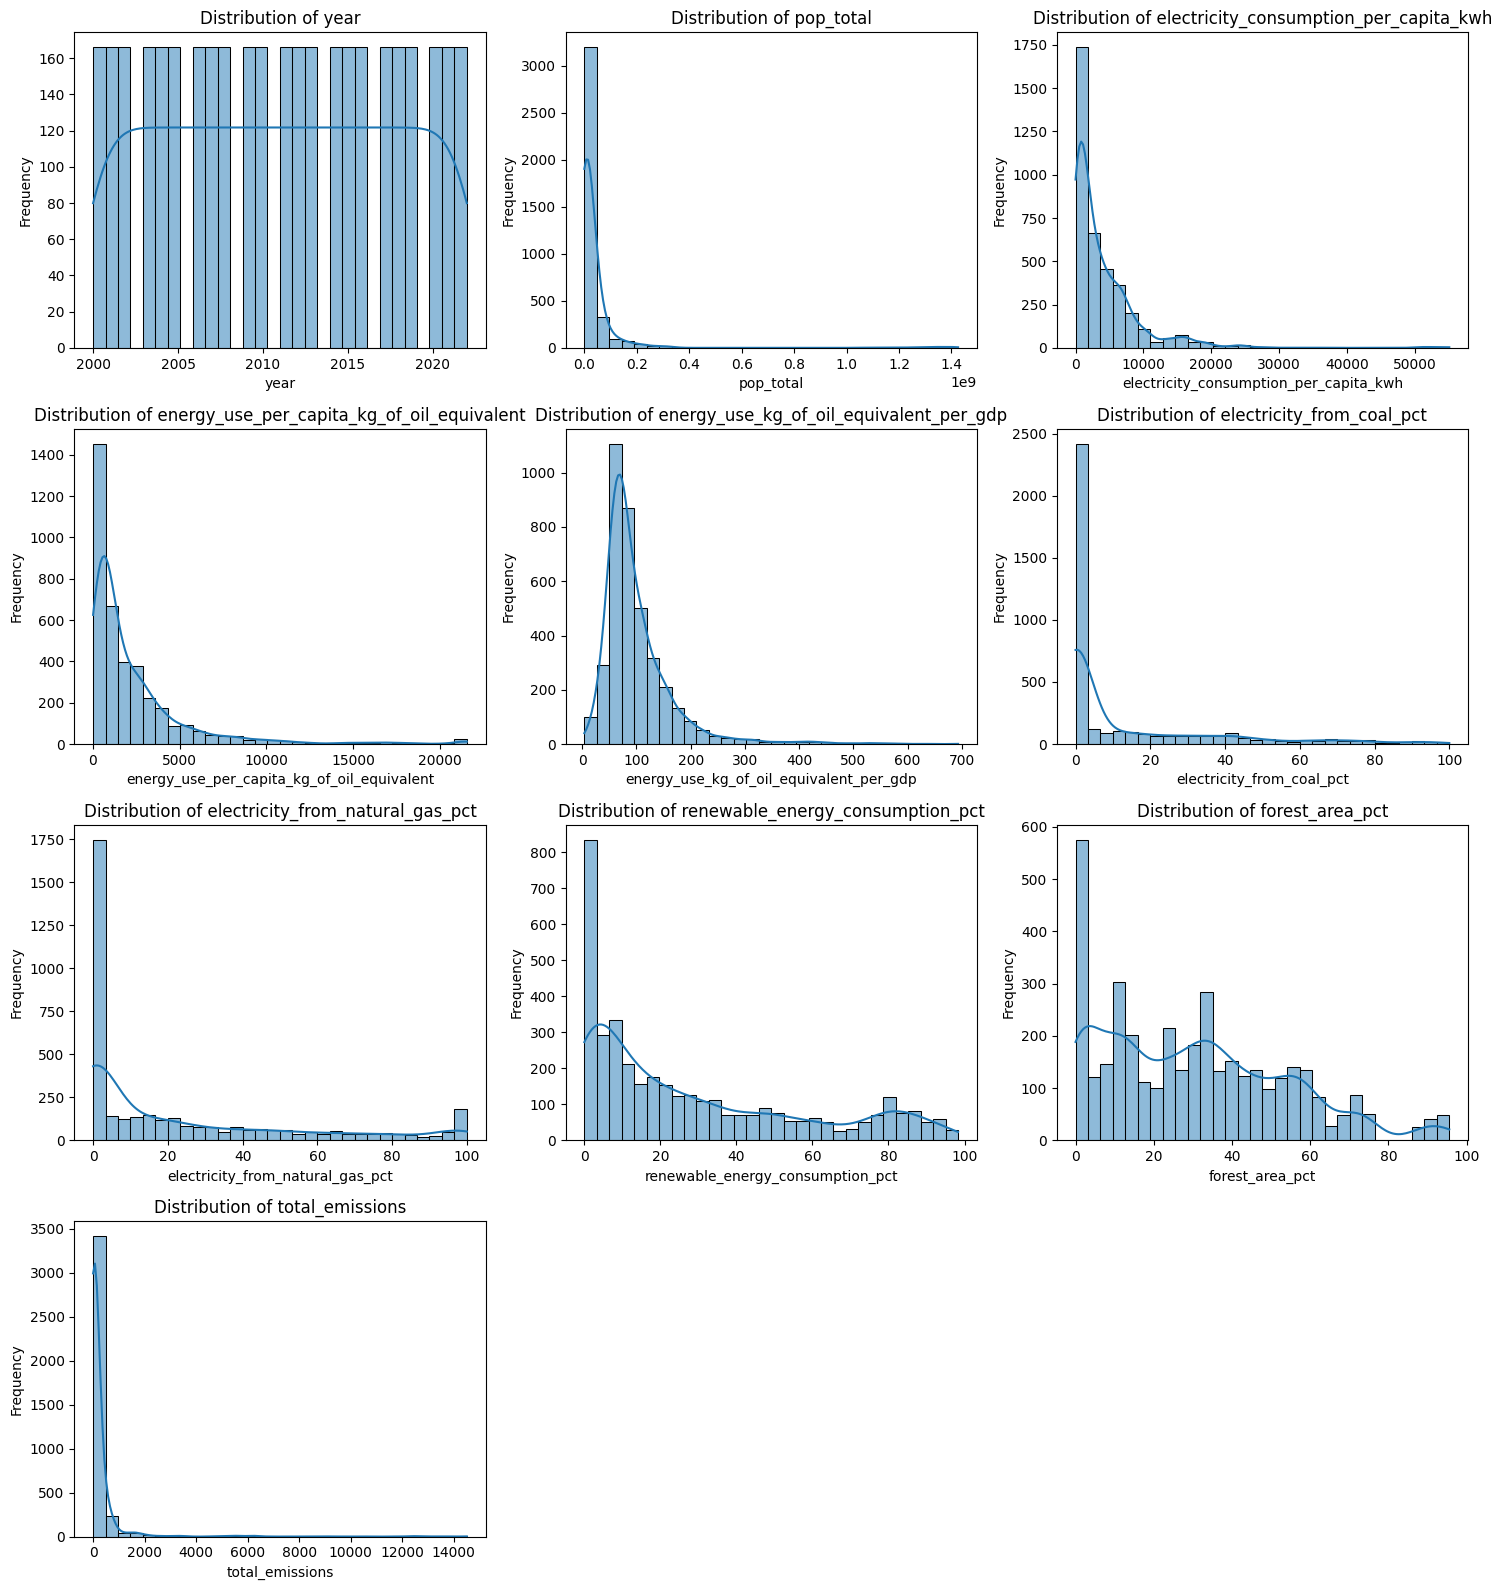

In [26]:
eda_utils.plot_numeric_fields_distributions(indicators_and_emissions_df)

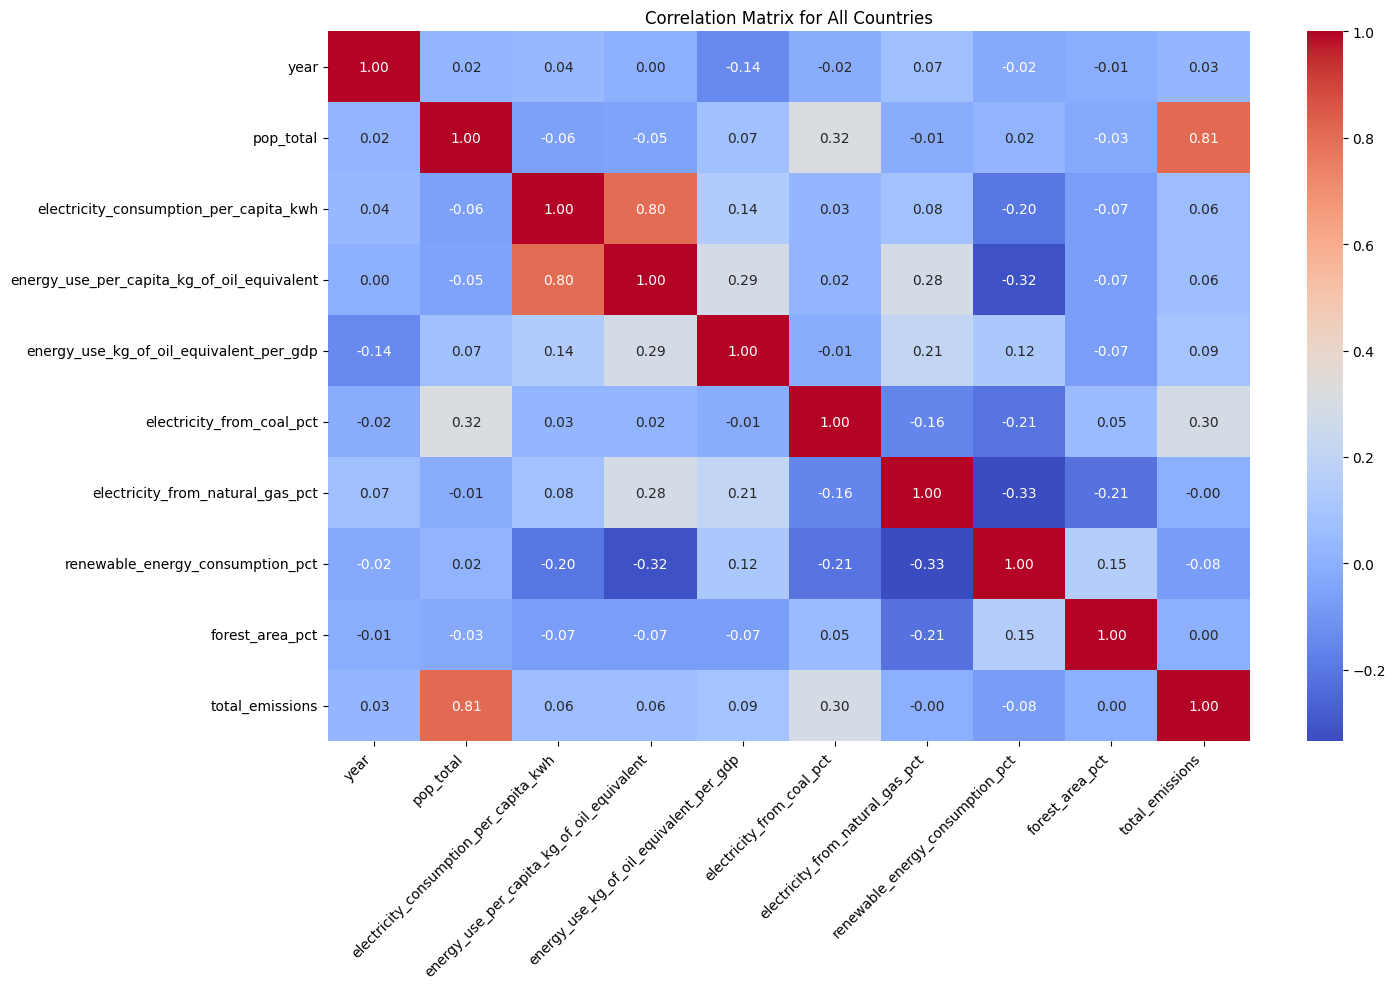

In [27]:
eda_utils.plot_correlation_matrix(indicators_and_emissions_df, figsize=(15,10))

## Feature Engineering for Numeric Features

In [28]:
numeric_cols = indicators_and_emissions_df.select_dtypes(include=["float64", "int64"]).columns.tolist()
numeric_cols_to_drop = ["year"]
numeric_cols = [col for col in numeric_cols if col not in numeric_cols_to_drop]
numeric_cols

['pop_total',
 'electricity_consumption_per_capita_kwh',
 'energy_use_per_capita_kg_of_oil_equivalent',
 'energy_use_kg_of_oil_equivalent_per_gdp',
 'electricity_from_coal_pct',
 'electricity_from_natural_gas_pct',
 'renewable_energy_consumption_pct',
 'forest_area_pct',
 'total_emissions']

In [29]:
indicators_and_emissions_df["total_emis_per_capita"] = (indicators_and_emissions_df["total_emissions"] * 1_000_000)/ indicators_and_emissions_df["pop_total"]

In [30]:
training_df = fe.log_transform_high_skew(indicators_and_emissions_df, numeric_cols, skew_threshold=1.0)
training_df.head()

Columns dropped due to high skewness: ['pop_total', 'electricity_consumption_per_capita_kwh', 'energy_use_per_capita_kg_of_oil_equivalent', 'energy_use_kg_of_oil_equivalent_per_gdp', 'electricity_from_coal_pct', 'electricity_from_natural_gas_pct', 'total_emissions']


,iso_alpha_3,year,renewable_energy_consumption_pct,forest_area_pct,total_emis_per_capita,log_pop_total,log_electricity_consumption_per_capita_kwh,log_energy_use_per_capita_kg_of_oil_equivalent,log_energy_use_kg_of_oil_equivalent_per_gdp,log_electricity_from_coal_pct,log_electricity_from_natural_gas_pct,log_total_emissions
0,ABW,2000,0.2,2.333333,3.706510,11.414088,5.975099,6.050022,4.063854,0.0,0.0,0.289504
22,ABW,2022,8.8,2.333333,4.628485,11.583486,5.975099,6.050022,4.063854,0.0,0.0,0.403251
21,ABW,2021,8.8,2.333333,4.449320,11.587114,5.975099,6.050022,4.063854,0.0,0.0,0.391496
20,ABW,2020,9.1,2.333333,4.556077,11.595316,5.975099,6.050022,4.063854,0.0,0.0,0.401946
19,ABW,2019,8.3,2.333333,5.272953,11.600973,5.975099,6.050022,4.063854,0.0,0.0,0.454777


In [31]:
training_df.describe()

,year,renewable_energy_consumption_pct,forest_area_pct,total_emis_per_capita,log_pop_total,log_electricity_consumption_per_capita_kwh,log_energy_use_per_capita_kg_of_oil_equivalent,log_energy_use_kg_of_oil_equivalent_per_gdp,log_electricity_from_coal_pct,log_electricity_from_natural_gas_pct,log_total_emissions
count,3818.000000,3818.000000,3818.000000,3818.000000,3818.000000,3818.000000,3818.000000,3818.000000,3818.000000,3818.000000,3818.000000
mean,2011.000000,28.499214,30.525895,8.968013,15.735255,7.407160,7.072348,4.457972,1.267855,1.936939,3.783759
std,6.634118,28.739741,23.404897,13.012065,2.170410,1.601142,1.214448,0.563008,1.651116,1.786528,1.932482
min,2000.000000,0.000000,0.000000,0.021223,9.778434,1.862776,2.372791,1.596894,0.000000,0.000000,0.009979
25%,2005.000000,4.700000,11.000806,2.727709,14.739356,6.498237,6.191805,4.131708,0.000000,0.000000,2.467292
50%,2011.000000,17.850000,28.673066,5.069870,16.034865,7.661008,7.029022,4.412300,0.000000,2.094488,3.951176
75%,2017.000000,46.975000,46.460675,9.806226,17.230831,8.633030,7.938756,4.781701,2.980584,3.666328,5.040060
max,2022.000000,98.300000,95.577213,203.942655,21.077735,10.916654,9.978524,6.542545,4.615121,4.615121,9.582746


In [32]:
training_df.isna().sum()

iso_alpha_3                                       0
year                                              0
renewable_energy_consumption_pct                  0
forest_area_pct                                   0
total_emis_per_capita                             0
log_pop_total                                     0
log_electricity_consumption_per_capita_kwh        0
log_energy_use_per_capita_kg_of_oil_equivalent    0
log_energy_use_kg_of_oil_equivalent_per_gdp       0
log_electricity_from_coal_pct                     0
log_electricity_from_natural_gas_pct              0
log_total_emissions                               0
dtype: int64

## EDA 2

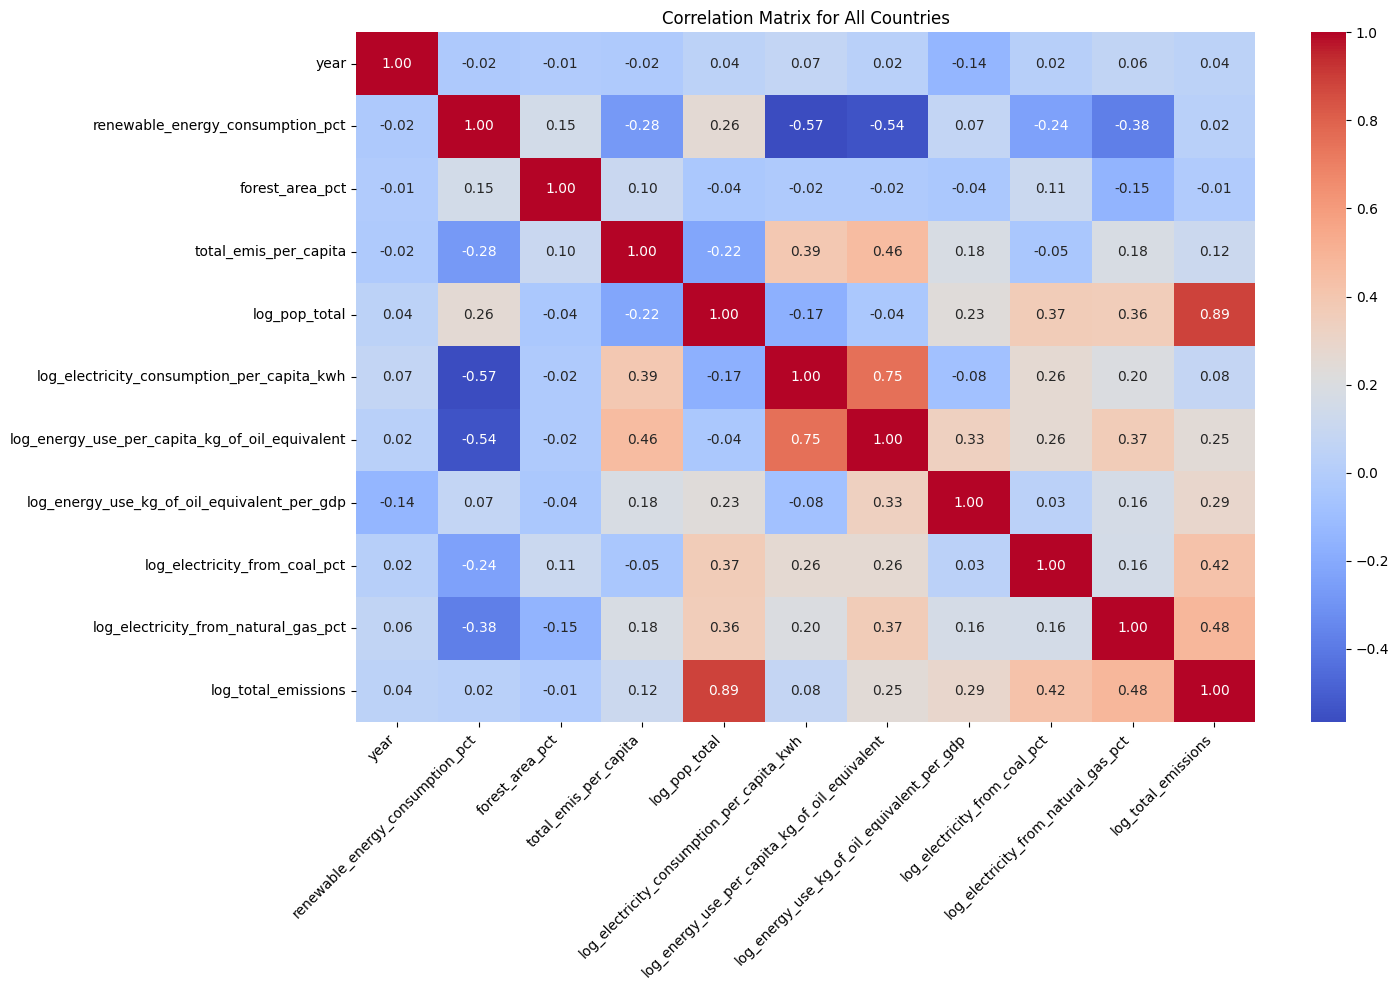

In [33]:
eda_utils.plot_correlation_matrix(training_df, figsize=(15,10))

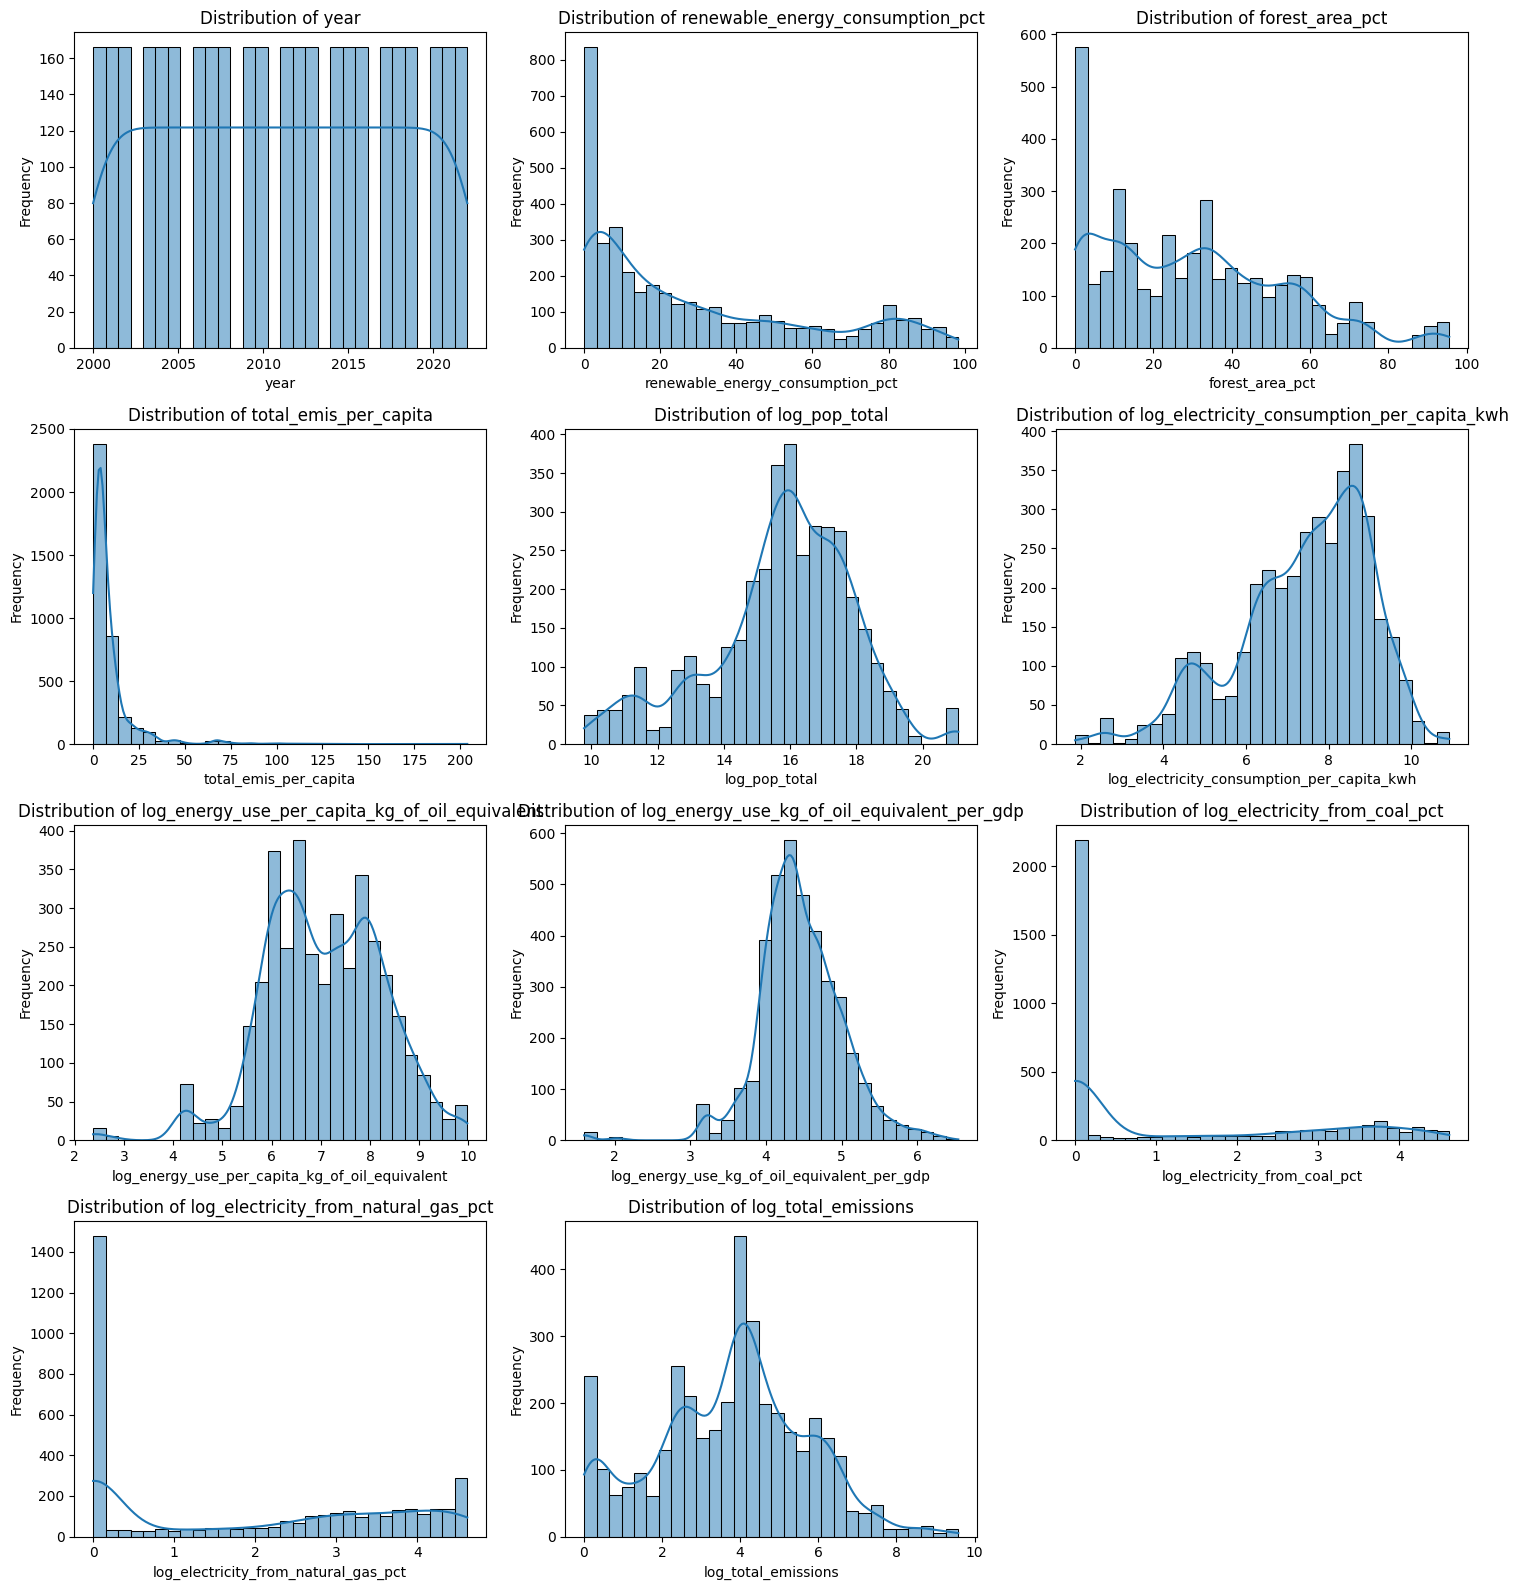

In [34]:
eda_utils.plot_numeric_fields_distributions(training_df)

In [35]:
# def check_for_multicollinearity(df, threshold=0.8, target_col="log_total_emissions"):
#     # Select only numeric columns except 'year'
#     numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
#     if "year" in numeric_cols:
#         numeric_cols.remove("year")
#         numeric_cols.remove(target_col)
#     corr_matrix = df[numeric_cols].corr().abs()
#     to_drop = set()
#     for i in range(len(corr_matrix.columns)):
#         for j in range(i):
#             if corr_matrix.iloc[i, j] >= threshold:
#                 colname = corr_matrix.columns[i]
#                 to_drop.add(colname)
#     print(f"Columns to drop due to multicollinearity (threshold={threshold}): {to_drop}")
#     return list(to_drop)

# check_for_multicollinearity(training_df, threshold=0.8)

## ML

In [36]:
training_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3818 entries, 0 to 3817
Data columns (total 12 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   iso_alpha_3                                     3818 non-null   object 
 1   year                                            3818 non-null   int64  
 2   renewable_energy_consumption_pct                3818 non-null   float64
 3   forest_area_pct                                 3818 non-null   float64
 4   total_emis_per_capita                           3818 non-null   float64
 5   log_pop_total                                   3818 non-null   float64
 6   log_electricity_consumption_per_capita_kwh      3818 non-null   float64
 7   log_energy_use_per_capita_kg_of_oil_equivalent  3818 non-null   float64
 8   log_energy_use_kg_of_oil_equivalent_per_gdp     3818 non-null   float64
 9   log_electricity_from_coal_pct                 

In [37]:
training_df_emissions_per_capita = training_df.drop(columns=["log_total_emissions", "log_pop_total"])
training_df_total_emissions = training_df.drop(columns=["total_emis_per_capita"])

In [42]:
from typing import List, Tuple, Dict, Any, Optional

def run_regression_analysis(
    df: pd.DataFrame,
    target_col: str,
    group_col: str,
    year_col: str,
    feature_cols: Optional[List[str]] = None,
    holdout_years: int = 5,
    lasso_alphas: np.ndarray = np.logspace(-4, 0, 50),
    enet_alphas: np.ndarray = np.logspace(-4, 0, 50),
    enet_l1_ratio: List[float] = [0.2, 0.5, 0.8],
    rf_params: Dict[str, Any] = None,
    ngb_params: Dict[str, Any] = None,
    plot_feature: str = "log_pop_total"
) -> Dict[str, Any]:
    """
    Run regression analysis with Random Forest, LassoCV, ElasticNetCV, and optionally NGBRegressor.
    Returns a dictionary with results, fitted models, coefficients, and plots.
    """
    # 1. Prepare data
    non_feature_cols = [group_col, year_col, target_col]
    if feature_cols is None:
        feature_cols = [c for c in df.columns if c not in non_feature_cols]
    X = df[feature_cols]
    y = df[target_col]
    groups = df[group_col]
    years = df[year_col]

    # 2. Train/test split (hold out last N years)
    cutoff_year = years.max() - holdout_years
    train_mask = years <= cutoff_year
    X_train = X.loc[train_mask]
    X_test  = X.loc[~train_mask]
    y_train = y.loc[train_mask]
    y_test  = y.loc[~train_mask]
    groups_train = groups.loc[train_mask]

    # 3. Define pipelines
    if rf_params is None:
        rf_params = dict(n_estimators=200, max_depth=None, random_state=42, n_jobs=-1)
    pipe_rf = Pipeline([
        ("rf", RandomForestRegressor(**rf_params)),
    ])

    pipe_lasso_cv = Pipeline([
        ("scaler", StandardScaler()),
        ("lasso", LassoCV(alphas=lasso_alphas, cv=5, random_state=42, n_jobs=-1))
    ])

    pipe_enet_cv = Pipeline([
        ("scaler", StandardScaler()),
        ("enet", ElasticNetCV(alphas=enet_alphas, l1_ratio=enet_l1_ratio, cv=5, random_state=42, n_jobs=-1))
    ])

    # 4. Cross-validation (MAE & R²)
    gkf = GroupKFold(n_splits=5)
    def cv_scores(pipe, scoring):
        return cross_val_score(
            pipe, X_train, y_train, groups=groups_train, cv=gkf, scoring=scoring, n_jobs=-1
        )

    # RF
    rf_mae = -cv_scores(pipe_rf, "neg_mean_absolute_error")
    rf_r2  =  cv_scores(pipe_rf, "r2")
    print(f"Random Forest MAE (CV): {rf_mae}, mean: {rf_mae.mean():.4f}")
    print(f"Random Forest R2 (CV): {rf_r2}, mean: {rf_r2.mean():.4f}")

    # LassoCV
    lasso_mae = -cv_scores(pipe_lasso_cv, "neg_mean_absolute_error")
    lasso_r2  =  cv_scores(pipe_lasso_cv, "r2")
    print(f"LassoCV MAE (CV): {lasso_mae}, mean: {lasso_mae.mean():.4f}")
    print(f"LassoCV R2 (CV): {lasso_r2}, mean: {lasso_r2.mean():.4f}")

    # ElasticNetCV
    enet_mae = -cv_scores(pipe_enet_cv, "neg_mean_absolute_error")
    enet_r2  =  cv_scores(pipe_enet_cv, "r2")
    print(f"ElasticNetCV MAE (CV): {enet_mae}, mean: {enet_mae.mean():.4f}")
    print(f"ElasticNetCV R2 (CV): {enet_r2}, mean: {enet_r2.mean():.4f}")

    # 5. Fit final models on full training set
    pipe_rf.fit(X_train, y_train)
    pipe_lasso_cv.fit(X_train, y_train)
    pipe_enet_cv.fit(X_train, y_train)
   

    # 7. Plot Lasso regularization path for a feature
    scaler = StandardScaler().fit(X_train)
    X_scaled = scaler.transform(X_train)
    alphas, coefs, _ = lasso_path(X_scaled, y_train, alphas=np.logspace(-4, 0, 100))
    if plot_feature in feature_cols:
        i = feature_cols.index(plot_feature)
        plt.figure()
        plt.plot(alphas, coefs[i], label=plot_feature)
        plt.xscale("log")
        plt.gca().invert_xaxis()
        plt.xlabel("Alpha")
        plt.ylabel("Coefficient")
        plt.title(f"Lasso Path for {plot_feature}")
        plt.legend()
        plt.tight_layout()
        plt.show()

    # 8. Feature importance plot for Random Forest
    importances = pipe_rf.named_steps["rf"].feature_importances_
    indices = np.argsort(importances)[::-1]
    plt.figure(figsize=(8, 6))
    plt.bar(range(len(importances)), importances[indices], align="center")
    plt.xticks(range(len(importances)), [feature_cols[i] for i in indices], rotation=90)
    plt.ylabel("Importance")
    plt.title("Random Forest Feature Importances")
    plt.tight_layout()
    plt.show()

    # Return all relevant objects/results
    pipeline_dict = {
        "rf_pipeline": pipe_rf,
        "lasso_pipeline": pipe_lasso_cv,
        "enet_pipeline": pipe_enet_cv
    }

    return pipeline_dict


Random Forest MAE (CV): [3.08252516 5.03517354 4.51109102 2.94595625 4.60230952], mean: 4.0354
Random Forest R2 (CV): [0.51462632 0.17948491 0.23781919 0.69483467 0.62938229], mean: 0.4512
LassoCV MAE (CV): [5.25766366 6.67196275 5.47589614 5.99176632 7.63559352], mean: 6.2066
LassoCV R2 (CV): [ 0.1098153   0.16880639  0.31185687 -0.02024434  0.19589099], mean: 0.1532
ElasticNetCV MAE (CV): [5.1435905  6.7031792  5.12273054 6.21636939 7.51390073], mean: 6.1400
ElasticNetCV R2 (CV): [0.19197305 0.18019305 0.3966398  0.00541372 0.20146724], mean: 0.1951


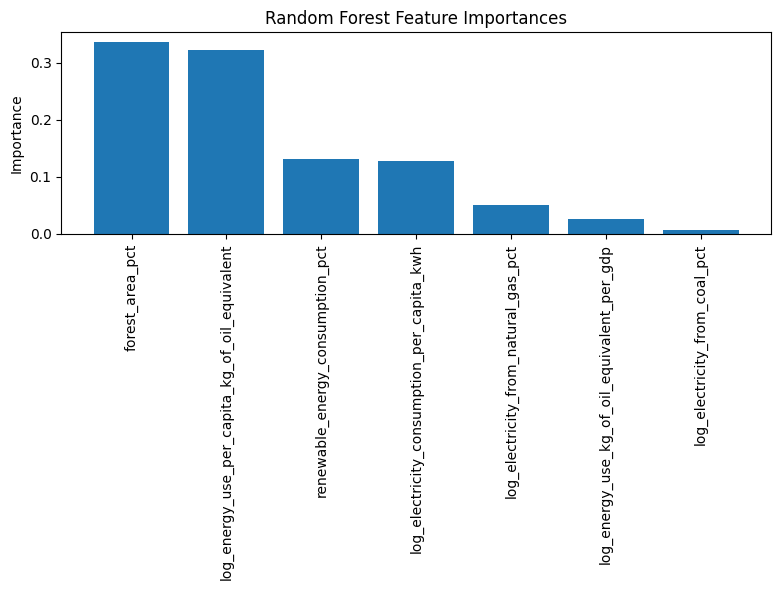

In [ ]:
# _ = run_regression_analysis(
#     df=training_df_emissions_per_capita,
#     target_col="total_emis_per_capita",
#     group_col="iso_alpha_3",
#     year_col="year",
#     feature_cols=None,
#     holdout_years=5,
#     lasso_alphas=np.logspace(-4, 0, 50),
#     enet_alphas=np.logspace(-4, 0, 50),
#     enet_l1_ratio=[0.2, 0.5, 0.8],
#     rf_params=dict(n_estimators=200, max_depth=None, random_state=42, n_jobs=-1),
# )

Random Forest MAE (CV): [0.45114088 0.57848892 0.57067523 0.67429105 0.52392756], mean: 0.5597
Random Forest R2 (CV): [0.88610785 0.8438382  0.8898107  0.73149725 0.8522851 ], mean: 0.8407
LassoCV MAE (CV): [0.52129081 0.50408159 0.59199945 0.6270784  0.65404668], mean: 0.5797
LassoCV R2 (CV): [0.88871711 0.89623081 0.89031847 0.78369164 0.78838391], mean: 0.8495
ElasticNetCV MAE (CV): [0.5233661  0.49479886 0.60372646 0.63255451 0.65535814], mean: 0.5820
ElasticNetCV R2 (CV): [0.88811145 0.90074926 0.88747631 0.78136557 0.78791404], mean: 0.8491


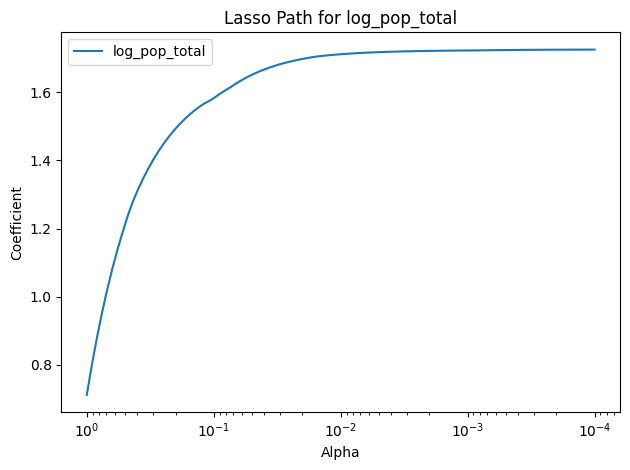

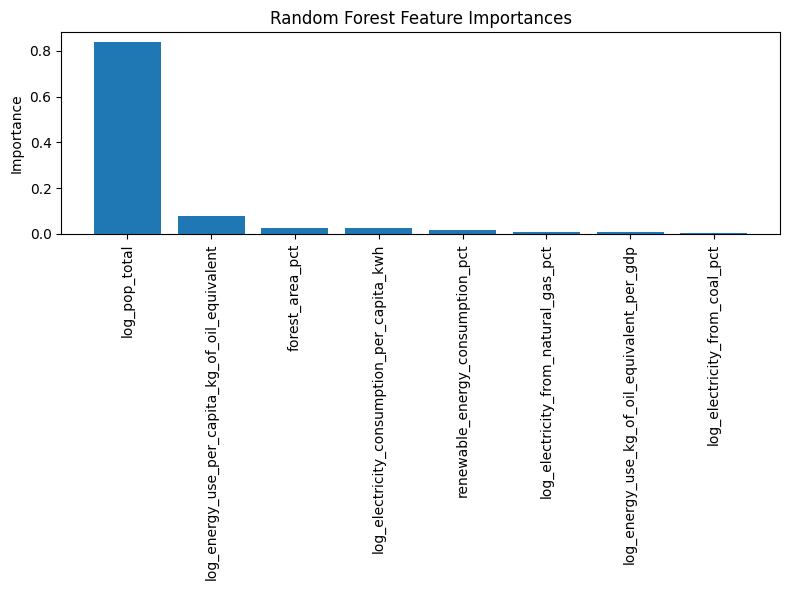

In [ ]:
pipeline_dict = run_regression_analysis(
    df=training_df_total_emissions,
    target_col="log_total_emissions",
    group_col="iso_alpha_3",
    year_col="year",
    feature_cols=None,
    holdout_years=5,
    lasso_alphas=np.logspace(-4, 0, 50),
    enet_alphas=np.logspace(-4, 0, 50),
    enet_l1_ratio=[0.2, 0.5, 0.8],
    rf_params=dict(n_estimators=200, max_depth=None, random_state=42, n_jobs=-1),
    ngb_params=dict(n_estimators=500, learning_rate=0.01, verbose=False, random_state=42),
    plot_feature="log_pop_total"
)

## Create projections

In [49]:
training_df_total_emissions

,iso_alpha_3,year,renewable_energy_consumption_pct,forest_area_pct,log_pop_total,log_electricity_consumption_per_capita_kwh,log_energy_use_per_capita_kg_of_oil_equivalent,log_energy_use_kg_of_oil_equivalent_per_gdp,log_electricity_from_coal_pct,log_electricity_from_natural_gas_pct,log_total_emissions
0,ABW,2000,0.2,2.333333,11.414088,5.975099,6.050022,4.063854,0.000000,0.0,0.289504
22,ABW,2022,8.8,2.333333,11.583486,5.975099,6.050022,4.063854,0.000000,0.0,0.403251
21,ABW,2021,8.8,2.333333,11.587114,5.975099,6.050022,4.063854,0.000000,0.0,0.391496
20,ABW,2020,9.1,2.333333,11.595316,5.975099,6.050022,4.063854,0.000000,0.0,0.401946
19,ABW,2019,8.3,2.333333,11.600973,5.975099,6.050022,4.063854,0.000000,0.0,0.454777
...,...,...,...,...,...,...,...,...,...,...,...
3796,ZWE,2001,72.3,47.356624,16.298073,6.767957,6.293919,4.888138,4.144395,0.0,3.519598
3795,ZWE,2000,69.5,47.475714,16.291381,6.800247,6.322423,4.924028,3.996277,0.0,3.454827
3816,ZWE,2021,82.4,44.974822,16.575344,6.293596,6.007630,4.854605,3.414581,0.0,3.845021
3805,ZWE,2010,81.2,46.284813,16.407517,6.359220,6.042701,5.101446,3.485115,0.0,3.831888


In [50]:
non_feature_cols = ["iso_alpha_3", "year", "log_total_emissions"]
feature_cols = [col for col in training_df_total_emissions.columns if col not in non_feature_cols]
feature_cols

['renewable_energy_consumption_pct',
 'forest_area_pct',
 'log_pop_total',
 'log_electricity_consumption_per_capita_kwh',
 'log_energy_use_per_capita_kg_of_oil_equivalent',
 'log_energy_use_kg_of_oil_equivalent_per_gdp',
 'log_electricity_from_coal_pct',
 'log_electricity_from_natural_gas_pct']